In [2]:
import pandas as pd
import os
from IPython.display import display, Image, HTML
import matplotlib.image as mpimg
from pathlib import Path
import matplotlib.pyplot as plt

# BÁO CÁO TỔNG HỢP KẾT QUẢ DỰ ÁN
## Phân Loại Tổn Thương Da Bằng Mô Hình ResNet Và ViT

Báo cáo này tổng hợp lại toàn bộ kết quả đạt được từ quá trình phân tích dữ liệu, huấn luyện trên tập HAM10000, transfer learning trên tập Derm7pt và so sánh hiệu năng giữa các mô hình.

In [3]:
def display_images_side_by_side(img_path1, img_path2, title1, title2):
    if not Path(img_path1).exists() or not Path(img_path2).exists():
        print(f"Lỗi: Không tìm thấy ảnh. Vui lòng kiểm tra lại đường dẫn!")
        return
        
    img1 = mpimg.imread(img_path1)
    img2 = mpimg.imread(img_path2)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    axes[0].imshow(img1)
    axes[0].set_title(title1, fontsize=14)
    axes[0].axis('off') 
    
    axes[1].imshow(img2)
    axes[1].set_title(title2, fontsize=14)
    axes[1].axis('off') 
    
    plt.tight_layout()
    plt.show()

def display_single_image(img_path, title, figsize=(8, 5)):
    if not os.path.exists(img_path):
        print(f"Cảnh báo: Không tìm thấy ảnh tại {img_path}")
        return
    img = mpimg.imread(img_path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title, fontsize=12, fontweight='bold', pad=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def display_log_csv(file_path, title):
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file log tại: {file_path}")
        return
    df = pd.read_csv(file_path)
    display(HTML(f"<h4>{title}</h4>"))
    
    if len(df) > 10:
        df_display = pd.concat([df.head(5), df.tail(5)])
        display(df_display.round(4))
    else:
        display(df.round(4))

---
### 1. Trực Quan Hóa Và Khám Phá Dữ Liệu (EDA)
Trước khi đi vào thống kê phân bố và huấn luyện, chúng ta cùng xem xét một số mẫu hình ảnh tổn thương da thực tế từ cả hai tập dữ liệu (HAM10000 và Derm7pt), cũng như phân tích đặc trưng về kích thước ảnh ban đầu.

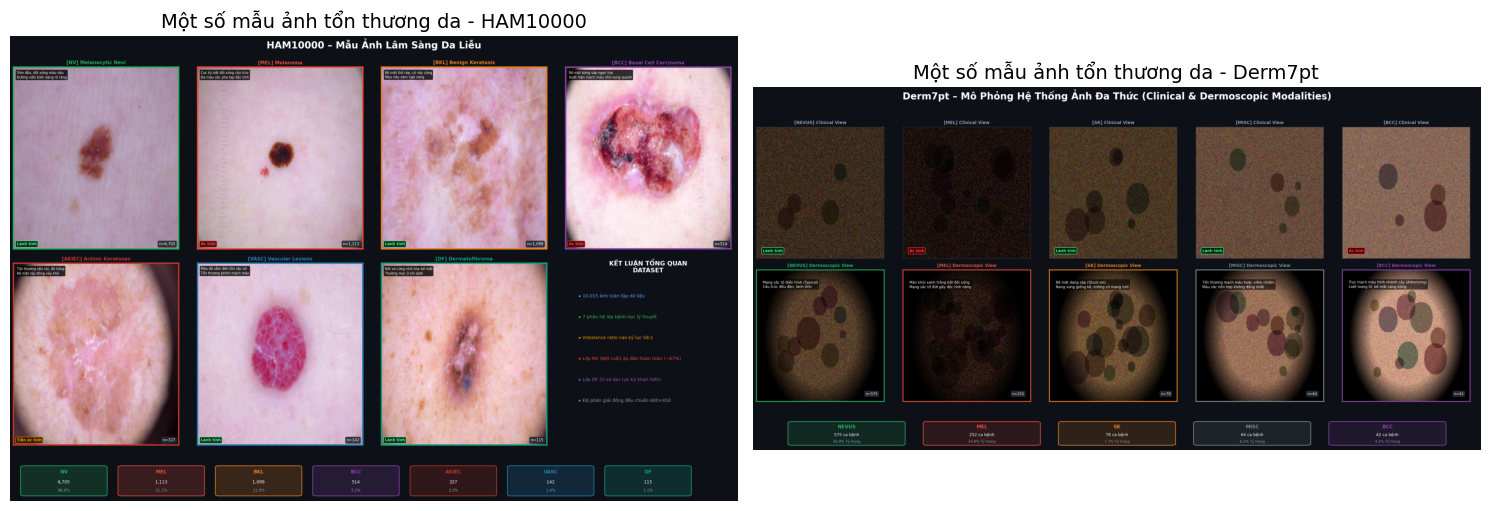

In [4]:
ham_samples = "../results/ham10000_outputs/fig4_sample_visualization.png"
derm_samples = "../results/derm7pt_outputs/fig4_sample_visualization_derm7pt.png"

display_images_side_by_side(
    ham_samples, 
    derm_samples, 
    "Một số mẫu ảnh tổn thương da - HAM10000", 
    "Một số mẫu ảnh tổn thương da - Derm7pt", 
)

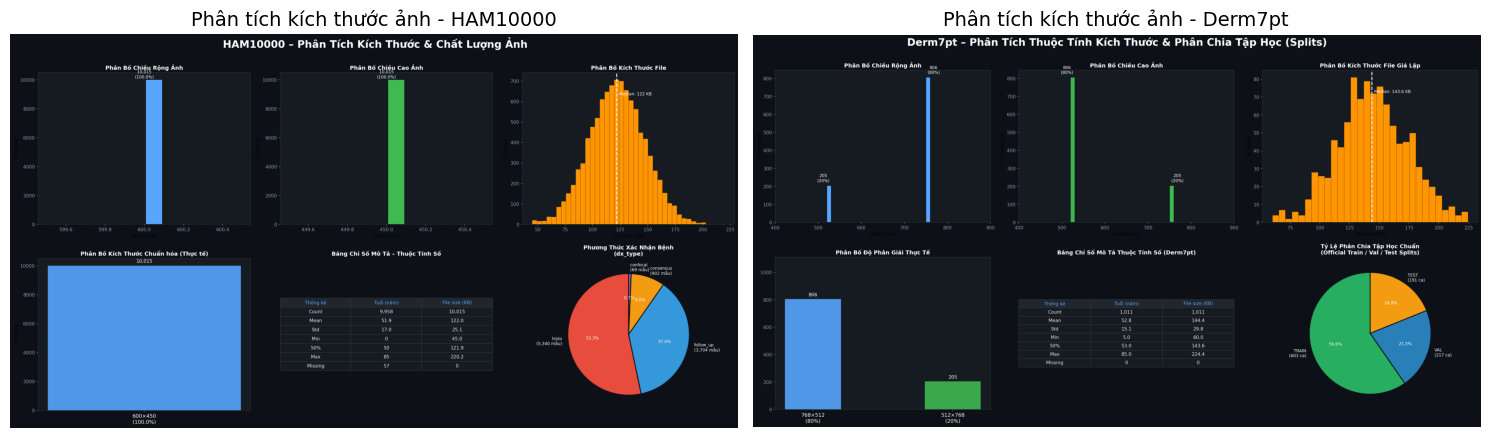

In [5]:
ham_size = "../results/ham10000_outputs/fig3_image_size_analysis.png"
derm_size = "../results/derm7pt_outputs/fig3_image_size_analysis_derm7pt.png"

display_images_side_by_side(
    ham_size, 
    derm_size, 
    "Phân tích kích thước ảnh - HAM10000", 
    "Phân tích kích thước ảnh - Derm7pt",
)

---
### 2. Phân Bố Dữ Liệu
Tổng quan về sự mất cân bằng dữ liệu giữa các nhãn trong cả hai tập dataset gốc HAM10000 và Derm7pt trước khi xử lý (augmentation).

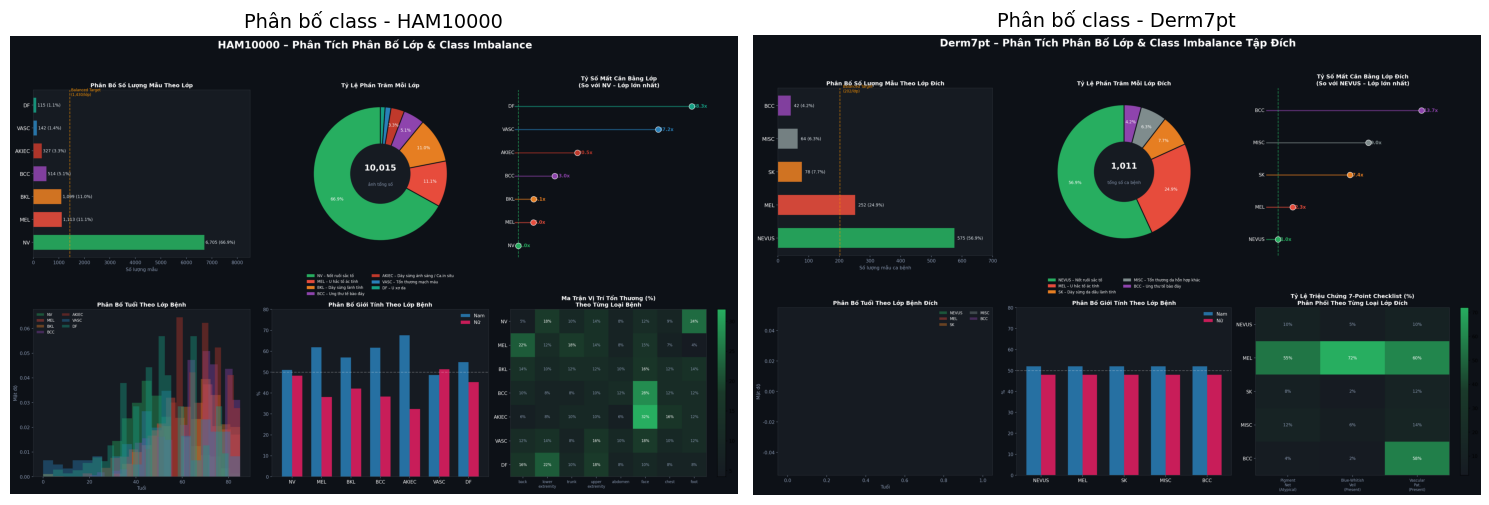

In [6]:
ham_dist = "../results/ham10000_outputs/fig2_class_distribution.png"
derm_dist = "../results/derm7pt_outputs/fig2_class_distribution_derm7pt.png"

display_images_side_by_side(ham_dist, derm_dist, "Phân bố class - HAM10000", "Phân bố class - Derm7pt")

---
### 3. Đường Cong Huấn Luyện Trên Tập HAM10000 (Base Models)
Biểu đồ theo dõi giá trị Loss và Accuracy của ResNet18 và Vision Transformer (ViT) qua các epoch huấn luyện chính thức trên tập dữ liệu HAM10000.

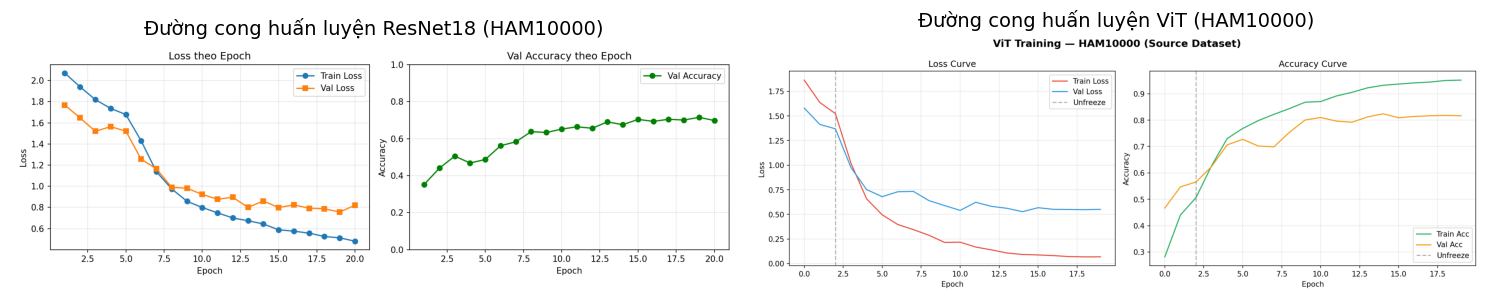

In [7]:
resnet_ham_curves = "../results/ph04_resnet_outputs/loss_val_resnet18.png"
vit_ham_curves = "../results/ph04_vit_outputs/vit_ham10000_training_curves.png"

display_images_side_by_side(resnet_ham_curves, vit_ham_curves, "Đường cong huấn luyện ResNet18 (HAM10000)", "Đường cong huấn luyện ViT (HAM10000)")

---
### 4. Kết Quả Fine-Tuning và Ma Trận Nhầm Lẫn (Derm7pt)
Sau khi học chuyển đổi sang tập Derm7pt, mô hình được đánh giá chi tiết bằng các ma trận nhầm lẫn (Confusion Matrix) nhằm kiểm tra khả năng phân loại sai lệch giữa các nhóm tổn thương da.

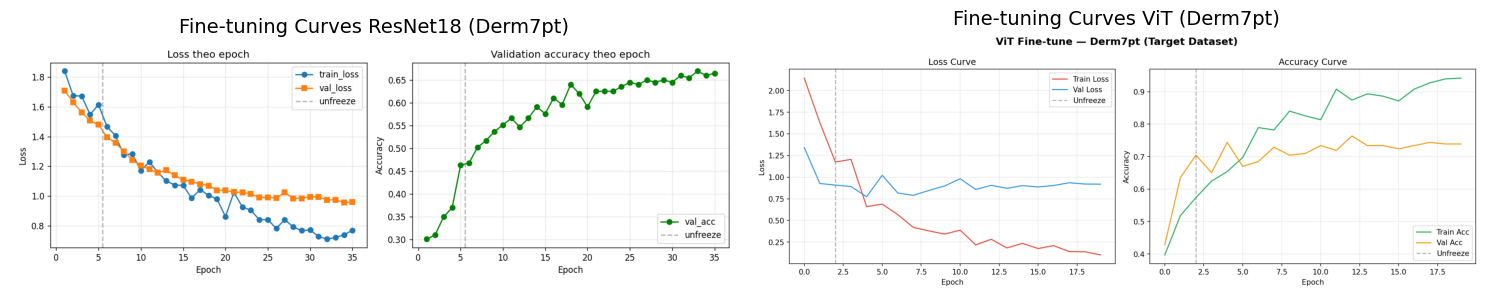

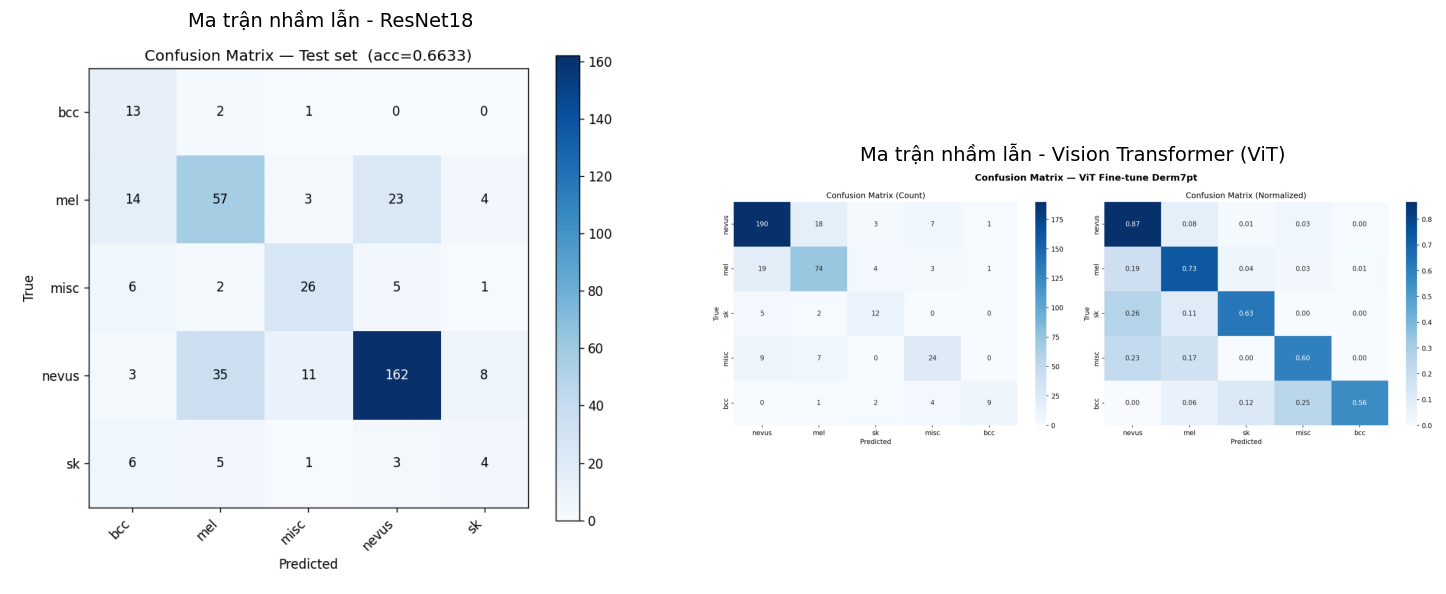

In [8]:
resnet_derm_curves = "../results/ph05_transfer_outputs/resnet18_derm7pt_training_curves.png"
vit_derm_curves = "../results/ph05_vit_transfer_outputs/vit_derm7pt_finetune_curves.png"

display_images_side_by_side(resnet_derm_curves, vit_derm_curves, "Fine-tuning Curves ResNet18 (Derm7pt)", "Fine-tuning Curves ViT (Derm7pt)")

resnet_cm = "../results/ph05_transfer_outputs/resnet18_derm7pt_confusion_matrix.png"
vit_cm = "../results/ph06_evaluation_outputs/ph06_evaluation_outputs/vit_confusion_matrix.png"

display_images_side_by_side(resnet_cm, vit_cm, "Ma trận nhầm lẫn - ResNet18", "Ma trận nhầm lẫn - Vision Transformer (ViT)")

---
### 5. Đánh Giá Tổng Hợp Và So Sánh Các Mô Hình
Bảng tổng hợp số liệu trích xuất từ file định dạng so sánh kết quả cuối cùng cùng hệ thống biểu đồ so sánh trực quan đa tiêu chí (Accuracy, Precision, Recall, F1-Score).

,Model,Accuracy,Precision,Recall,F1-Score
0,ViT (fine-tune Derm7pt),0.7823,0.7825,0.7823,0.7813


,Class,Precision (ResNet18),Precision (ViT),Recall (ResNet18),Recall (ViT),F1-Score (ResNet18),F1-Score (ViT)
0,bcc,0.31,0.82,0.81,0.56,0.45,0.67
1,mel,0.56,0.73,0.56,0.73,0.56,0.73
2,misc,0.62,0.63,0.65,0.60,0.63,0.62
3,nevus,0.84,0.85,0.74,0.87,0.79,0.86
4,sk,0.24,0.57,0.21,0.63,0.22,0.60


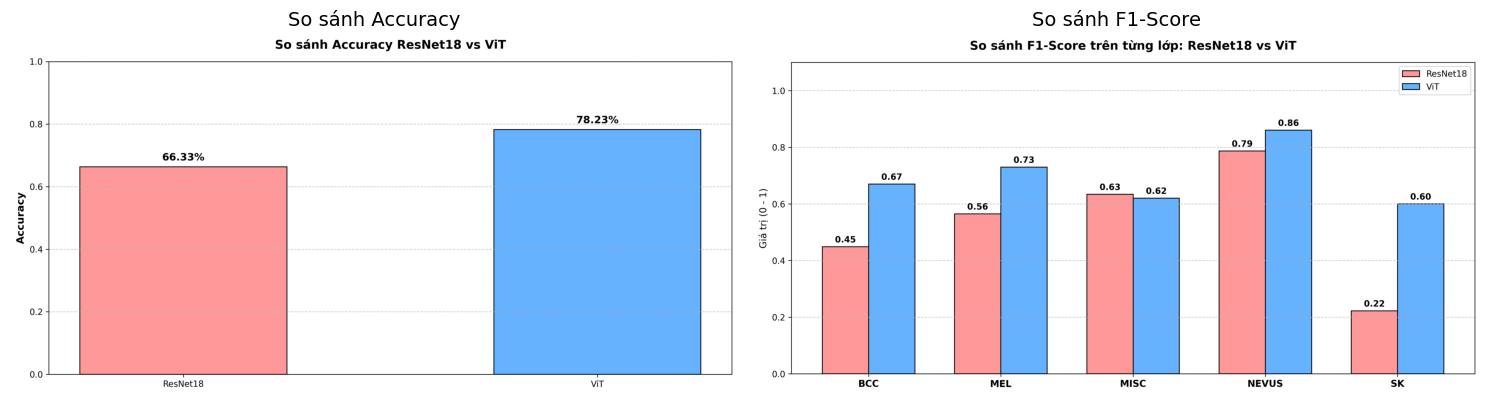

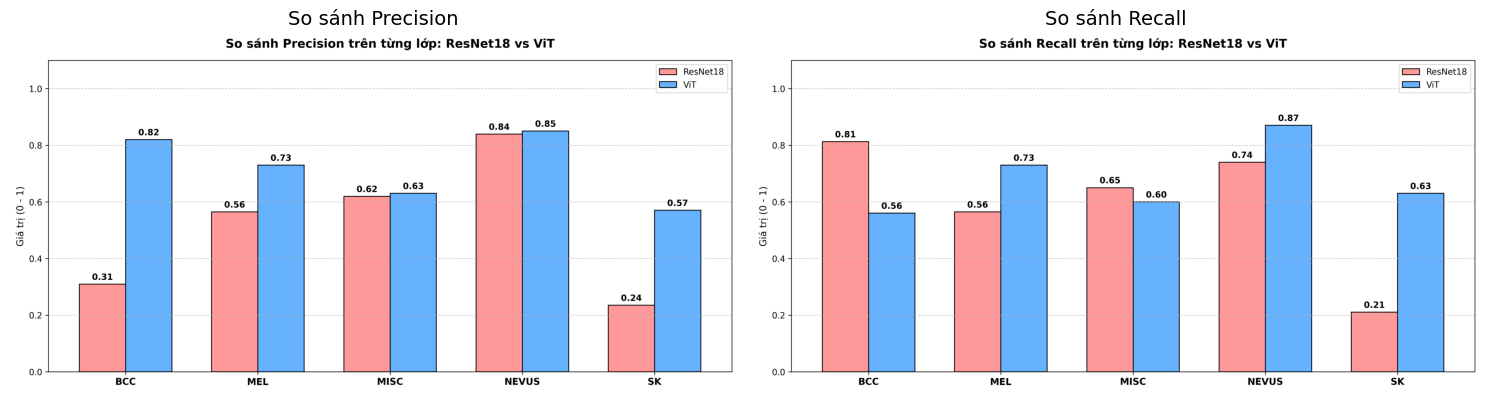

In [9]:
vit_summary_csv = "../results/ph06_evaluation_outputs/ph06_evaluation_outputs/vit_metrics_summary.csv"
display_log_csv(vit_summary_csv, "Bảng Chỉ Số Đánh Giá Chi Tiết (ViT Summary Metrics)")

summary_csv = "../results/ph07_model_comparison/metrics_comparison_summary.csv"

if os.path.exists(summary_csv):
    df_summary = pd.read_csv(summary_csv)
    display(HTML("<h3>Bảng Chỉ Số Đánh Giá Mô Hình Tổng Hợp</h3>"))
    display(df_summary.round(4))
else:
    print(f"Không tìm thấy file báo cáo tổng hợp: {summary_csv}")

acc_comp = "../results/ph07_model_comparison/accuracy_comparison.png"
f1_comp = "../results/ph07_model_comparison/f1_score_comparison.png"
precision_comp = "../results/ph07_model_comparison/precision_comparison.png"
recall_comp = "../results/ph07_model_comparison/recall_comparison.png"

display_images_side_by_side(acc_comp, f1_comp, "So sánh Accuracy", "So sánh F1-Score")
display_images_side_by_side(precision_comp, recall_comp, "So sánh Precision", "So sánh Recall")

---
### 6. Chi Tiết Lịch Sử Quá Trình Huấn Luyện (Training Logs)
Dữ liệu số liệu cụ thể thu được trực tiếp trong quá trình tối ưu hóa các tham số mạng ResNet18 được lưu trữ tại phân mục lưu trữ hệ thống log của project.

In [10]:
log_resnet_ham = "../logs/resnet18_log.csv"
log_resnet_derm = "../logs/resnet18_derm7pt_log.csv"

display_log_csv(log_resnet_ham, "1. Lịch sử huấn luyện ResNet18 trên tập dữ liệu HAM10000")
display_log_csv(log_resnet_derm, "2. Lịch sử Fine-Tuning ResNet18 trên tập dữ liệu Derm7pt")

,epoch,train_loss,val_loss,val_acc,lr
0,1,2.0704,1.7685,0.3523,0.0001
1,2,1.9401,1.6466,0.4407,0.0001
2,3,1.8196,1.5198,0.5056,0.0001
3,4,1.7363,1.5641,0.4682,0.0001
4,5,1.6781,1.5211,0.4872,0.0001
15,16,0.5756,0.8242,0.6935,0.0001
16,17,0.5566,0.7920,0.7046,0.0001
17,18,0.5254,0.7874,0.7007,0.0001
18,19,0.5121,0.7566,0.7151,0.0001
19,20,0.4806,0.8207,0.6981,0.0001


,epoch,train_loss,val_loss,val_acc,lr
0,1,1.8410,1.7094,0.3005,0.0003
1,2,1.6758,1.6313,0.3103,0.0003
2,3,1.6729,1.5632,0.3498,0.0003
3,4,1.5487,1.5072,0.3695,0.0003
4,5,1.6139,1.4805,0.4631,0.0003
30,31,0.7275,0.9933,0.6601,0.0003
31,32,0.7087,0.9728,0.6552,0.0003
32,33,0.7205,0.9743,0.6700,0.0003
33,34,0.7378,0.9561,0.6601,0.0003
34,35,0.7687,0.9596,0.6650,0.0003


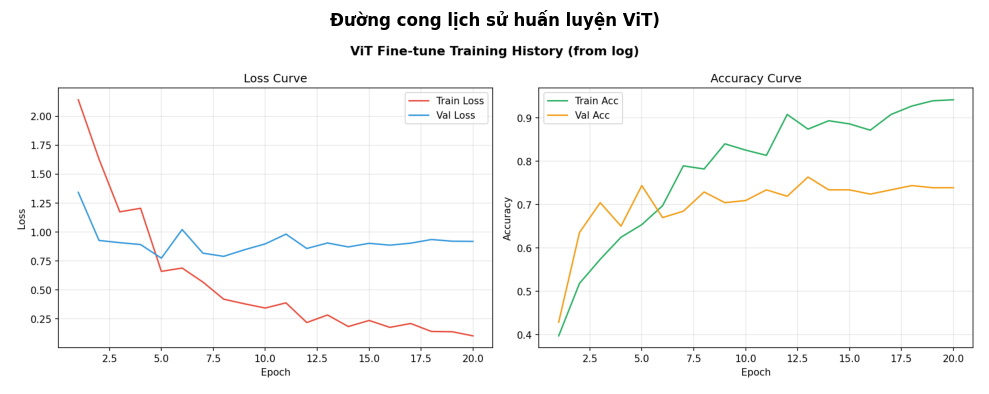

In [11]:
vit_history_img = "../results/ph06_evaluation_outputs/ph06_evaluation_outputs/vit_training_history_from_log.png"
display_single_image(vit_history_img, "Đường cong lịch sử huấn luyện ViT)", figsize=(10, 5))

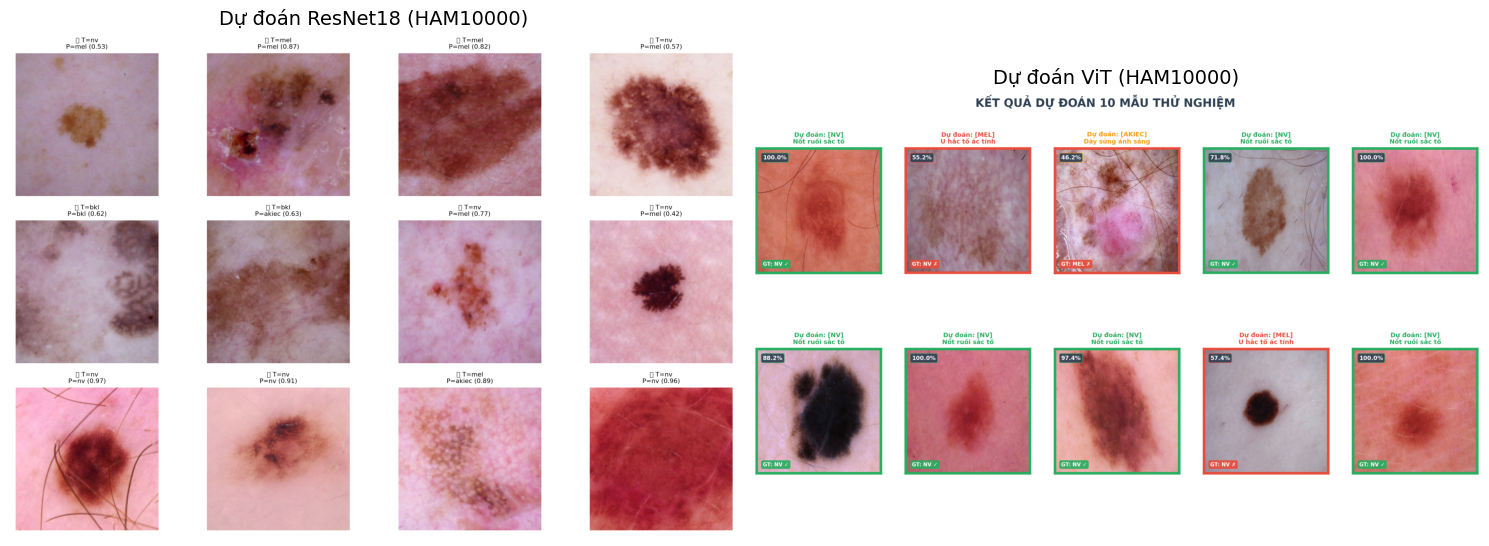

In [12]:
resnet_ham_prediction = "../results/ph04_resnet_outputs/resnet_ham10000_val_predictions.png"
vit_ham_prediction = "../results/ph04_vit_outputs/predict_all_10_samples.png"

display_images_side_by_side(resnet_ham_prediction, vit_ham_prediction, "Dự đoán ResNet18 (HAM10000)", "Dự đoán ViT (HAM10000)")

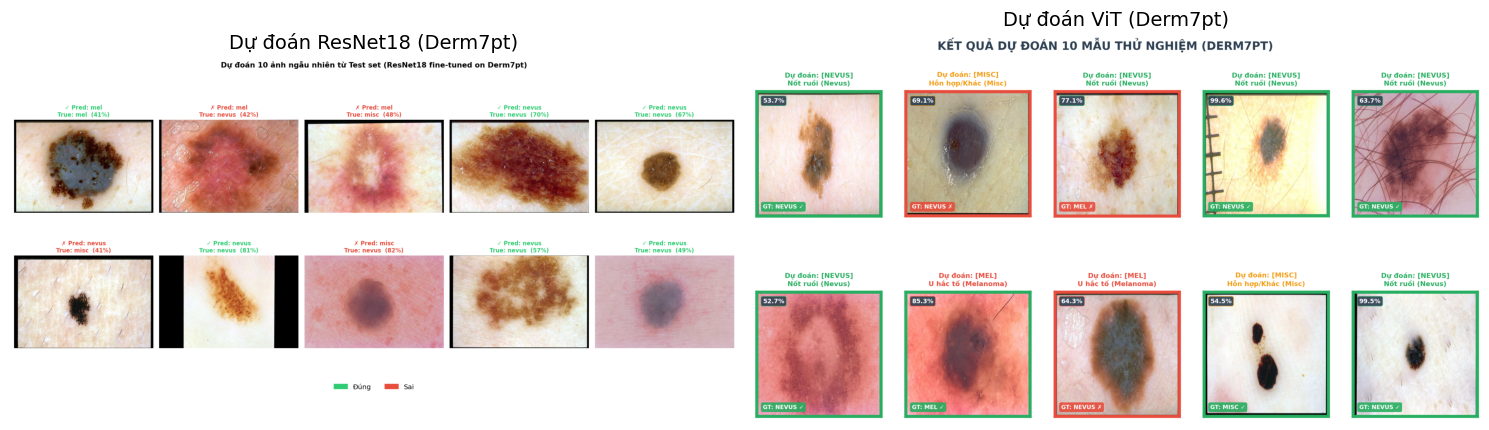

In [13]:
resnet_derm7pt_prediction = "../results/ph05_transfer_outputs/resnet18_derm7pt_sample_predictions.png"
vit_derm7pt_prediction = "../results/ph05_vit_transfer_outputs/vit_derm7pt_predictions.png"

display_images_side_by_side(resnet_derm7pt_prediction, vit_derm7pt_prediction, "Dự đoán ResNet18 (Derm7pt)", "Dự đoán ViT (Derm7pt)")